# RL-6b - Actor-Critic : unir valeur et politique

**Serie** : Reinforcement Learning | **Notebook** : 6b/13 | **Duree estimee** : 45-50 min

Navigation : [RL-1 Intro](rl_1_intro_cartpole.ipynb) | [RL-2 Wrappers](rl_2_wrappers_sauvegarde_callbacks.ipynb) | [RL-3 HER](rl_3_experience_replay_her.ipynb) | [RL-4 Bandits](rl_4_multi_armed_bandits.ipynb) | [RL-5 Tabulaire](rl_5_mdp_dp_qlearning.ipynb) | [RL-6 DQN/PG](rl_6_dqn_policy_gradient.ipynb) | **RL-6b** | [RL-7 Multi-Agent](rl_7_multi_agent_rl.ipynb)

***

## Objectifs d'apprentissage

A la fin de ce notebook, vous serez capable de :
- Comprendre le paradigme Actor-Critic qui combine les approches value-based et policy-based
- Implementer l'algorithme A2C (Advantage Actor-Critic) depuis zero en PyTorch
- Comparer la reduction de variance apportee par le critic par rapport a REINFORCE
- Explorer le rôle du bonus d'entropie dans l'exploration

## Prerequis

- [RL-5 MDP/Q-Learning tabulaire](rl_5_mdp_dp_qlearning.ipynb) (concepts Q-value, TD learning)
- [RL-6 DQN et Policy Gradient](rl_6_dqn_policy_gradient.ipynb) (DQN, REINFORCE)
- Bases de PyTorch (`nn.Module`, `autograd`, `torch.distributions`)

***

**Pourquoi Actor-Critic ?**
Dans le notebook précédent (RL-6), nous avons vu deux paradigmes :
- **DQN** (value-based) : apprend $Q(s,a)$, stable mais limite aux actions discretes
- **REINFORCE** (policy-based) : apprend directement $\pi(a \mid s)$, flexible mais haute variance

L'Actor-Critic **combine les deux** : un reseau *actor* apprend la politique, tandis qu'un reseau *critic* estime la valeur des etats pour reduire la variance des gradients. C'est le fondement d'algorithmes modernes comme PPO, SAC et TD3.

## 1. Du REINFORCE a l'Actor-Critic

### Le problème de variance dans REINFORCE

REINFORCE estime le gradient de la politique avec le retour Monte Carlo $G_t$ :

$$\nabla_\theta J(\theta) \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t  \mid s_t) \cdot G_t$$

Le problème : $G_t$ a une **variance très elevee** car il cumule toutes les recompenses futures. Pour un episode de 200 pas, $G_t$ peut varier de 0 a 200, ce qui rend les mises a jour instables.

### La solution : une baseline apprise

L'idee est de remplacer $G_t$ par l'**avantage** $A(s_t, a_t)$ :

$$A(s_t, a_t) = G_t - V(s_t)$$

ou $V(s_t)$ est la **valeur attendue de l'etat** $s_t$, estimee par le *critic*. L'avantage mesure **a quel point l'action choisie est meilleure que la moyenne** pour cet etat.

**Propriete fondamentale** : l'avantage reduit la variance sans introduire de biais. Si $V(s_t)$ est une bonne estimation, l'avantage sera proche de zero pour les actions mediocres et positif pour les bonnes actions.

### Architecture Actor-Critic

| Composant | Rôle | Sortie |
|-----------|------|--------|
| **Actor** | Politique $\pi(a \mid s)$ | Distribution de probabilite sur les actions |
| **Critic** | Valeur $V(s)$ | Scalaire estimant le retour attendu |

Les deux reseaux apprennent simultanement :
- L'actor est mis a jour par **policy gradient** avec l'avantage comme signal
- Le critic est mis a jour par **TD learning** pour mieux estimer $V(s)$

> **Lien avec RL-6** : L'exercice 3 du notebook précédent demandait exactement d'ajouter un critic a REINFORCE. Ce notebook developpe cette idee en detail.


> *Ancres savantes -- Williams, R.J. (1992), Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning, Neural Computation 4(3):405-414 (REINFORCE, ligne de base dont Actor-Critic reduit la variance) ; Konda, V.R. & Tsitsiklis, J.N. (2003), On Actor-Critic Algorithms, SIAM Journal on Control and Optimization 42(4):1143-1166 (cadre actor-critic, le critic estime la ligne de base V(s) pour reduire la variance du gradient) ; Mnih, V., Badia, A.P., Mirza, M., Graves, A., Lillicrap, T., Harley, T., Silver, D. & Kavukcuoglu, K. (2016), Asynchronous Methods for Deep Reinforcement Learning, ICML 2016, arXiv:1602.01783 (A3C / sa variante synchrone A2C, acteur-critique on-policy dont ce notebook implemente le coeur) ; Sutton, R.S., McAllester, D.A., Singh, S.P. & Mansour, Y. (2000), Policy Gradient Methods for RL with Function Approximation, NeurIPS 2000 (theoreme du gradient de politique).*

## 2. Installation et imports

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from collections import deque

print(f"Imports OK : gymnasium {gym.__version__}, torch {torch.__version__}")

# Dimensions de l'environnement CartPole-v1
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
print(f"State dim : {state_dim}, Action dim : {action_dim}")
env.close()

Imports OK : gymnasium 1.2.3, torch 2.13.0+cpu
State dim : 4, Action dim : 2


Nous travaillons sur CartPole-v1, le même environnement que dans les notebooks précédents. L'espace d'observation est continu (4 dimensions) et l'espace d'action est discret (2 actions). Ce choix permet de comparer directement avec REINFORCE et DQN.

## 3. Le Critic -- Reseau de valeur V(s)

Le critic est un reseau de neurones qui estime $V(s)$, la valeur attendue d'un etat. Pour rappel :

$$V(s) = \mathbb{E}\left[\sum_{t=0}^{\infty} \gamma^t r_t \mid s_0 = s\right]$$

Contrairement au DQN qui estime $Q(s,a)$ pour chaque action, le critic produit un **unique scalaire** par etat. Cela le rend plus simple a entrainer car la cible est directe : le retour observe $G_t$.

In [2]:
class CriticNetwork(nn.Module):
    """Reseau de valeur V(s) : estime la valeur attendue d'un etat."""

    def __init__(self, state_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state):
        return self.net(state)


# Verification des dimensions
critic = CriticNetwork(state_dim)
dummy_state = torch.randn(1, state_dim)
value = critic(dummy_state)
print(f"CriticNetwork defini : input={state_dim}, output=1 (valeur scalaire)")
print(f"Test forward : V(s) = {value.item():.4f}")
print(f"Nombre de parametres : {sum(p.numel() for p in critic.parameters())}")

CriticNetwork defini : input=4, output=1 (valeur scalaire)
Test forward : V(s) = 0.1920
Nombre de parametres : 17281


Le critic est un MLP a 3 couches (comme le Q-network du DQN) mais avec une sortie de dimension 1 au lieu de `action_dim`. Il partage la même architecture que l'actor pour maintenir un equilibre de capacite entre les deux reseaux.

## 4. L'Actor -- Politique parametree

L'actor est un reseau de neurones qui produit une **distribution de probabilite** sur les actions $\pi(a \mid s)$. Il est identique au `PolicyNetwork` de REINFORCE vu dans RL-6.

La différence cle : dans REINFORCE, les gradients sont ponderes par $G_t$ (retour Monte Carlo). Dans Actor-Critic, ils seront ponderes par l'avantage $A_t = G_t - V(s_t)$.

In [3]:
class ActorNetwork(nn.Module):
    """Politique parametree pi(a|s) : produit une distribution sur les actions."""

    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, state):
        probs = self.net(state)
        dist = Categorical(probs)
        return dist


# Verification des dimensions
actor = ActorNetwork(state_dim, action_dim)
dummy_state = torch.randn(1, state_dim)
dist = actor(dummy_state)
print(f"ActorNetwork defini : input={state_dim}, output={action_dim} (distribution)")
print(f"Probabilites : {dist.probs.detach().numpy().flatten()}")
print(f"Nombre de parametres : {sum(p.numel() for p in actor.parameters())}")

ActorNetwork defini : input=4, output=2 (distribution)
Probabilites : [0.5265148  0.47348517]
Nombre de parametres : 17410


L'actor utilise une couche `Softmax` en sortie pour garantir que les probabilites sommennt a 1. La classe `Categorical` de PyTorch permet d'echantillonner des actions et de calculer les log-probabilites necessaires pour le policy gradient.

## 5. Calcul de l'avantage -- le coeur d'A2C

L'avantage est la cle de voute de l'algorithme Actor-Critic. Il quantifie a quel point l'action choisie est **meilleure que la moyenne** :

$$A(s_t, a_t) = G_t - V(s_t)$$

- Si $A > 0$ : l'action est meilleure que prevu --> renforcer cette action
- Si $A < 0$ : l'action est pire que prevu --> diminuer sa probabilite

**Le trick `.detach()`** : lors du calcul de l'avantage, on detache $V(s_t)$ du graphe de calcul. Cela empeche les gradients de l'actor de modifier le critic. Sans cela, l'actor pourrait "tromper" le critic pour faciliter son propre apprentissage.

Les pertes combinees sont :

$$\mathcal{L}_{total} = \underbrace{-\frac{1}{N}\sum_t \log \pi(a_t \mid s_t) \cdot A_t}_{\text{Actor loss}} + \alpha \underbrace{\frac{1}{N}\sum_t (V(s_t) - G_t)^2}_{\text{Critic loss}} - \beta \underbrace{H(\pi)}_{\text{Entropy bonus}}$$

ou $\alpha$ est le coefficient de la perte valeur et $\beta$ le coefficient d'entropie.

### Exercice 1 : Calcul de l'avantage et de la perte actor-critic

Implementez la fonction `compute_advantage_and_loss` qui calcule la perte totale A2C.

**Indices** :
- `# Indice` : L'avantage = returns - values.detach(). Le `.detach()` est crucial pour stopper le gradient du critic
- `# Indice` : La perte de l'actor = -(log_probs * advantage).mean(). C'est le policy gradient avec avantage
- `# Indice` : La perte du critic = F.mse_loss(values, returns). C'est une regression vers les retours
- `# Indice` : L'entropie = dist.entropy().mean(). Elle mesure l'incertitude de la politique

**Étapes** :
- `# Étape 1` : Calculez l'avantage en detachant les values du graphe
- `# Étape 2` : Calculez la perte de l'actor (n'oubliez pas le signe negatif)
- `# Étape 3` : Calculez la perte du critic (MSE entre predictions et cibles)
- `# Étape 4` : Calculez l'entropie et la perte totale

In [4]:
# Exercice 1 : Calcul de l'avantage et de la perte actor-critic
#
# Completez la fonction compute_advantage_and_loss qui :
# 1. Calcule l'avantage A_t = returns - values (detached du gradient)
# 2. Calcule la perte de l'actor (policy gradient avec avantage)
# 3. Calcule la perte du critic (MSE entre values et returns)
# 4. Calcule le bonus d'entropie
# 5. Retourne la perte totale = actor_loss + value_coef * critic_loss - entropy_coef * entropy


def compute_advantage_and_loss(dist, values, returns, value_coef=0.5, entropy_coef=0.01):
    """
    Calcule la perte totale Actor-Critic.

    Arguments:
        dist: distribution Categorical de l'actor
        values: tensor [batch_size] des valeurs estimees par le critic
        returns: tensor [batch_size] des returns accumules
        value_coef: poids de la perte du critic
        entropy_coef: poids du bonus d'entropie

    Retourne:
        loss: perte totale (scalaire)
        actor_loss: perte de l'actor (scalaire)
        critic_loss: perte du critic (scalaire)
        entropy: entropie moyenne (scalaire)
    """
    # TODO etudiant : calculer l'avantage
    advantage = None  # TODO etudiant : returns - values.detach()

    # TODO etudiant : perte de l'actor (policy gradient avec avantage)
    actor_loss = None  # TODO etudiant : -(log_probs * advantage).mean()

    # TODO etudiant : perte du critic (MSE)
    critic_loss = None  # TODO etudiant : F.mse_loss(values, returns)

    # TODO etudiant : bonus d'entropie
    entropy = None  # TODO etudiant : dist.entropy().mean()

    # TODO etudiant : perte totale
    loss = None  # TODO etudiant : actor_loss + value_coef * critic_loss - entropy_coef * entropy

    return loss, actor_loss, critic_loss, entropy


# Test rapide avec des tenseurs factices pour verifier la signature
print("Exercice a completer : implementer compute_advantage_and_loss")

Exercice a completer : implementer compute_advantage_and_loss


## 6. L'agent A2C complet

Maintenant que nous avons l'actor, le critic et le calcul d'avantage, nous pouvons assembler l'agent A2C complet. L'agent encapsule :
- La **sélection d'action** via l'actor
- Le **calcul des retours** actualises
- La **mise a jour** conjointe des deux reseaux avec un optimizer partage
- Le **gradient clipping** pour stabiliser l'apprentissage

In [5]:
class A2CAgent:
    """Agent Advantage Actor-Critic complet."""

    def __init__(self, state_dim, action_dim, lr=7e-4, gamma=0.99,
                 value_coef=0.5, entropy_coef=0.01):
        self.actor = ActorNetwork(state_dim, action_dim)
        self.critic = CriticNetwork(state_dim)
        self.optimizer = torch.optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()),
            lr=lr
        )
        self.gamma = gamma
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef

    def select_action(self, state):
        """Selectionne une action selon la politique de l'actor."""
        state_t = torch.FloatTensor(state).unsqueeze(0)
        dist = self.actor(state_t)
        action = dist.sample()
        return action.item(), dist.log_prob(action), dist

    def compute_returns(self, rewards, next_value, dones):
        """Calcule les retours actualises en partant de la fin."""
        returns = []
        R = next_value
        for reward, done in zip(reversed(rewards), reversed(dones)):
            R = reward + self.gamma * R * (1 - done)
            returns.insert(0, R)
        return torch.tensor(returns, dtype=torch.float32)

    def update(self, states, actions, returns):
        """Met a jour actor et critic conjointement.

        Recalcule log_probs, values et entropy a partir du meme forward pass
        pour garantir la coherence du graphe de calcul PyTorch.
        """
        states_t = torch.FloatTensor(np.array(states))
        actions_t = torch.LongTensor(actions)

        # Forward pass unique pour actor : log_probs + entropy
        dist = self.actor(states_t)
        log_probs = dist.log_prob(actions_t)
        entropy = dist.entropy().mean()

        # Forward pass critic : values
        values = self.critic(states_t).squeeze()

        # Advantage et pertes
        advantage = returns - values.detach()
        actor_loss = -(log_probs * advantage).mean()
        critic_loss = F.mse_loss(values, returns)

        loss = actor_loss + self.value_coef * critic_loss - self.entropy_coef * entropy

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping pour stabiliser l'apprentissage
        torch.nn.utils.clip_grad_norm_(
            list(self.actor.parameters()) + list(self.critic.parameters()),
            max_norm=1.0
        )
        self.optimizer.step()

        return loss.item(), actor_loss.item(), critic_loss.item(), entropy.item()


# Creation de l'agent
agent_a2c = A2CAgent(state_dim, action_dim)
actor_params = sum(p.numel() for p in agent_a2c.actor.parameters())
critic_params = sum(p.numel() for p in agent_a2c.critic.parameters())
print(f"A2CAgent defini avec actor ({actor_params} params) "
      f"+ critic ({critic_params} params)")
print(f"Optimizer partage : Adam, lr=7e-4")
print(f"Gamma={agent_a2c.gamma}, value_coef={agent_a2c.value_coef}, "
      f"entropy_coef={agent_a2c.entropy_coef}")

A2CAgent defini avec actor (17410 params) + critic (17281 params)
Optimizer partage : Adam, lr=7e-4
Gamma=0.99, value_coef=0.5, entropy_coef=0.01


L'agent utilise un **optimizer partage** pour l'actor et le critic. Cela simplifie l'implementation et assure que les deux reseaux progressent a un rythme coherent. Le **gradient clipping** (max_norm=1.0) prevent les mises a jour trop agressives qui pourraient destabiliser l'apprentissage.

**Point cle de l'implementation** : la méthode `update()` recalcule les `log_probs` et l'entropie a partir d'un nouveau forward pass de l'actor sur les etats collectes, plutot que de reutiliser les `log_probs` calcules lors de la collecte. Cela garantit la **coherence du graphe de calcul** PyTorch : log_probs, advantage et entropy derivent tous du même etat des poids du reseau, ce qui produit des gradients corrects pour la retropropagation.

## 7. Entrainement sur CartPole-v1

La boucle d'entrainement suit le schema classique du RL :
1. Collecter une trajectoire complete (episode)
2. Calculer les retours actualises avec bootstrap de la valeur finale
3. Mettre a jour actor et critic conjointement

**Point important** : contrairement au DQN qui met a jour a chaque pas (off-policy avec replay buffer), A2C met a jour **a la fin de chaque episode** (on-policy). Les données ne sont reutilisees qu'une seule fois.

In [6]:
def train_a2c(env_name="CartPole-v1", num_episodes=600, eval_interval=50, seed=42):
    """
    Entraine un agent A2C sur un environnement Gymnasium.

    Arguments:
        env_name: nom de l'environnement
        num_episodes: nombre d'episodes d'entrainement
        eval_interval: frequence d'affichage des statistiques
        seed: graine aleatoire pour la reproductibilite

    Retourne:
        episode_rewards: liste des recompenses par episode
    """
    # Reproductibilite
    torch.manual_seed(seed)
    np.random.seed(seed)

    env = gym.make(env_name)
    s_dim = env.observation_space.shape[0]
    a_dim = env.action_space.n

    agent = A2CAgent(s_dim, a_dim)

    episode_rewards = []
    running_reward = deque(maxlen=100)

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)
        states, actions, rewards, dones = [], [], [], []
        episode_reward = 0

        done = False
        while not done:
            action, log_prob, dist = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            states.append(state)
            actions.append(action)
            rewards.append(reward)
            dones.append(float(terminated))
            episode_reward += reward
            state = next_state

        # Bootstrap value pour le dernier etat
        next_value = 0 if terminated else agent.critic(
            torch.FloatTensor(state).unsqueeze(0)
        ).item()
        returns = agent.compute_returns(rewards, next_value, dones)

        # update() recalcule log_probs, values et entropy en interne
        # pour garantir la coherence du graphe de calcul
        agent.update(states, actions, returns)

        episode_rewards.append(episode_reward)
        running_reward.append(episode_reward)

        if (episode + 1) % eval_interval == 0:
            avg = np.mean(running_reward)
            print(f"Episode {episode+1:3d}/{num_episodes} | "
                  f"Reward moyen (100 ep): {avg:.1f}")

    env.close()
    return episode_rewards


# Entrainement
rewards_a2c = train_a2c(num_episodes=600)
final_avg = np.mean(rewards_a2c[-100:])
print(f"\nEntrainement termine. Reward final moyen (100 ep): {final_avg:.1f}")

Episode  50/600 | Reward moyen (100 ep): 20.6


Episode 100/600 | Reward moyen (100 ep): 17.7


Episode 150/600 | Reward moyen (100 ep): 13.8


Episode 200/600 | Reward moyen (100 ep): 23.6


Episode 250/600 | Reward moyen (100 ep): 48.7


...

Episode 400/600 | Reward moyen (100 ep): 190.5


Episode 450/600 | Reward moyen (100 ep): 237.1


Episode 500/600 | Reward moyen (100 ep): 295.8


Episode 550/600 | Reward moyen (100 ep): 339.7


Episode 600/600 | Reward moyen (100 ep): 349.3

Entrainement termine. Reward final moyen (100 ep): 349.3


**Detail subtil : `terminated` vs `truncated` (API Gymnasium >= 0.26).**

Depuis Gymnasium, `env.step` renvoie cinq valeurs dont `terminated` et `truncated` sont **distinctes** :
- `terminated = True` : l'episode s'est termine *naturellement* (le pole est tombe, fin de partie) -> il n'y a pas de futur a bootstrapper.
- `truncated = True` : simple *depassement de budget* (limite de 500 pas sur CartPole-v1) -> l'agent aurait pu continuer, l'etat final reste « vivant ».

Pour le calcul du retour, on **n'annule le bootstrap de la valeur critique que sur `terminated`**. Un episode tronque reste un episode en cours : `V(s_dernier)` est une estimée valide du futur, donc `next_value = 0 if terminated else critic(...)`. La variable `done = terminated or truncated` ne sert qu'au **controle de la boucle** (sortir de l'episode), jamais au masque du bootstrap. On retrouve la meme convention dans le DQN du notebook rl_6, qui stocke `float(terminated)` dans son replay buffer.

L'entrainement devrait montrer une progression reguliere vers le seuil de resolution (475 sur CartPole-v1). Le critic reduit la variance des mises a jour par rapport a REINFORCE, ce qui se traduit par une convergence plus stable.

## 8. Visualisation des résultats

Analysons la courbe d'apprentissage et la distribution des rewards finaux pour evaluer la stabilite de l'agent.

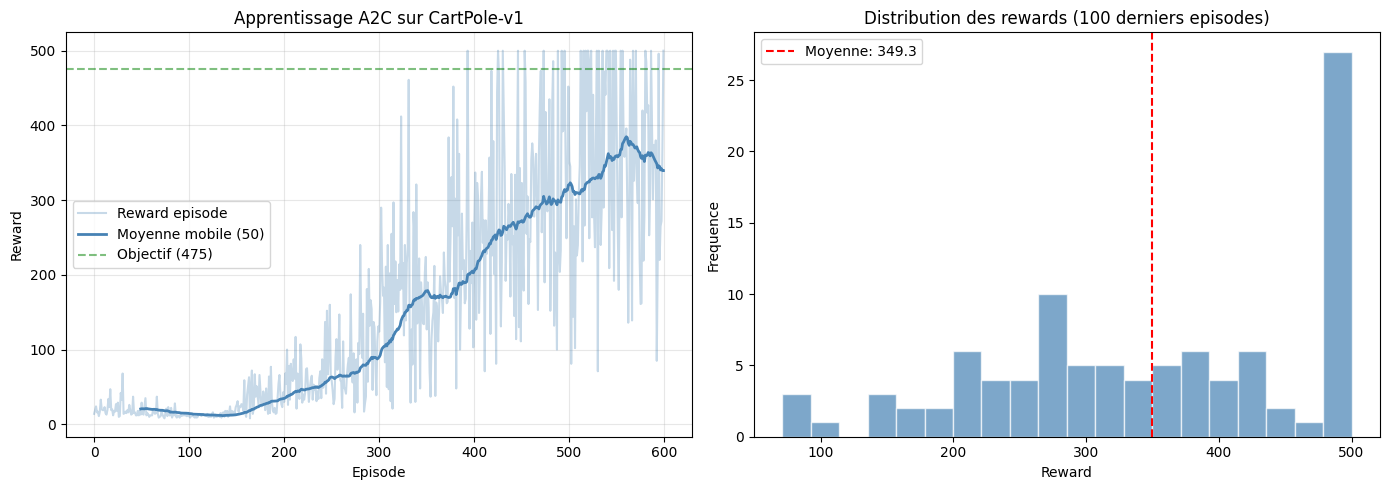

Visualisation A2C generee. Reward moyen final: 349.3 +/- 121.8


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de reward
axes[0].plot(rewards_a2c, alpha=0.3, color='steelblue', label='Reward episode')
window = 50
if len(rewards_a2c) >= window:
    moving_avg = np.convolve(rewards_a2c, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(rewards_a2c)), moving_avg,
                 color='steelblue', linewidth=2, label=f'Moyenne mobile ({window})')
axes[0].axhline(y=475, color='green', linestyle='--', alpha=0.5, label='Objectif (475)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].set_title('Apprentissage A2C sur CartPole-v1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution des rewards finaux
final_rewards = rewards_a2c[-100:]
axes[1].hist(final_rewards, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(x=np.mean(final_rewards), color='red', linestyle='--',
                label=f'Moyenne: {np.mean(final_rewards):.1f}')
axes[1].set_xlabel('Reward')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Distribution des rewards (100 derniers episodes)')
axes[1].legend()

plt.tight_layout()
plt.savefig('a2c_cartpole_results.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Visualisation A2C generee. Reward moyen final: "
      f"{np.mean(final_rewards):.1f} +/- {np.std(final_rewards):.1f}")

## 9. Comparaison avec REINFORCE

L'avantage principal d'Actor-Critic sur REINFORCE est la **reduction de variance** des gradients. Avec REINFORCE, le signal de gradient est multiplie par $G_t$ (qui peut varier enormement). Avec A2C, le signal est multiplie par l'avantage $A_t = G_t - V(s_t)$, qui est centre et de plus petite amplitude.

### Exercice 2 : Comparaison A2C vs REINFORCE

Comparez les courbes d'apprentissage des deux algorithmes sur CartPole-v1.

**Indices** :
- `# Indice` : Reutilisez la classe PolicyNetwork et la boucle REINFORCE du notebook rl_6
- `# Indice` : Entrainenez les deux agents avec le même nombre d'episodes et le même random seed
- `# Indice` : La perte REINFORCE est -(log_probs * returns).mean() sans avantage

**Étapes** :
- `# Étape 1` : Implementez une version simplifiee de REINFORCE (ou importez depuis rl_6)
- `# Étape 2` : Lancez les deux entrainements avec les mêmes hyperparametres
- `# Étape 3` : Tracez les deux courbes sur le même graphe avec moyenne mobile

### 9.1 La mesure executee : REINFORCE vs A2C sur 5 graines

Le claim fondateur de ce notebook -- *le critic reduit la variance de REINFORCE* -- ne peut pas se juger sur le run unique ci-dessus (seed 42). Une courbe d'apprentissage seule confond deux dispersions differentes :

- la **dispersion inter-episodes** : le nuage des 600 points d'un meme run (c'est ce que montre la figure de la section 8) ;
- la **dispersion inter-graines** : la variabilite du resultat final quand on reentraine tout depuis le debut -- c'est celle-ci qui mesure la robustesse d'un algorithme.

On execute donc les deux algorithmes sur **5 graines** {42, 0, 1, 7, 99}, meme environnement (CartPole-v1), **meme budget** de 400 episodes, meme architecture d'actor (couches 128, lr 7e-4). Le REINFORCE ci-dessous est la version *sans critic* exactement telle que annoncee en section 1 : perte $-(\log \pi(a_t \mid s_t) \cdot G_t)$ sur les retours bruts, sans baseline ni normalisation -- c'est precisement la variance de ce signal qu'on veut observer.

> Le protocole suit le standard de la serie (ablation multi-graines de rl_6) : mediane et IQR inter-graines sur la performance finale (moyenne des 50 dernieres episodes) et sur la vitesse de convergence (premier episode ou la moyenne mobile depasse 150).

In [8]:
def train_reinforce_measured(env_name="CartPole-v1", num_episodes=400, seed=42):
    """REINFORCE sans baseline -- la reference que le critic doit battre.

    Meme ActorNetwork, meme lr que l'A2C ci-dessus : seule l'absence du
    critic (donc l'absence de baseline) differencie les deux algorithmes.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    env = gym.make(env_name)
    actor = ActorNetwork(env.observation_space.shape[0], env.action_space.n)
    optimizer = torch.optim.Adam(actor.parameters(), lr=7e-4)

    episode_rewards = []
    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)
        log_probs, rewards = [], []
        done = False
        while not done:
            dist = actor(torch.FloatTensor(state).unsqueeze(0))
            action = dist.sample()
            log_probs.append(dist.log_prob(action))
            state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            rewards.append(reward)

        # Retours actualises bruts : pas de baseline, pas de normalisation
        returns = torch.zeros(len(rewards))
        R = 0.0
        for t in reversed(range(len(rewards))):
            R = rewards[t] + 0.99 * R
            returns[t] = R

        loss = -(torch.stack(log_probs).flatten() * returns).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        episode_rewards.append(sum(rewards))
    env.close()
    return episode_rewards


ABL_SEEDS = [42, 0, 1, 7, 99]
ABL_EPISODES = 400

abl_curves = {"A2C": {}, "REINFORCE": {}}
for algo, runner in [
    ("A2C", lambda s: train_a2c(num_episodes=ABL_EPISODES,
                                eval_interval=ABL_EPISODES, seed=s)),
    ("REINFORCE", lambda s: train_reinforce_measured(num_episodes=ABL_EPISODES,
                                                     seed=s)),
]:
    for s in ABL_SEEDS:
        curve = runner(s)
        abl_curves[algo][s] = curve
        print(f"{algo:10s} seed={s:2d} | final (50 dernieres ep) : "
              f"{np.mean(curve[-50:]):7.1f}")

Episode 400/400 | Reward moyen (100 ep): 190.5
A2C        seed=42 | final (50 dernieres ep) :   202.7


Episode 400/400 | Reward moyen (100 ep): 207.2
A2C        seed= 0 | final (50 dernieres ep) :   226.3


Episode 400/400 | Reward moyen (100 ep): 167.2
A2C        seed= 1 | final (50 dernieres ep) :   183.6


Episode 400/400 | Reward moyen (100 ep): 165.6
A2C        seed= 7 | final (50 dernieres ep) :   189.2


Episode 400/400 | Reward moyen (100 ep): 169.0
A2C        seed=99 | final (50 dernieres ep) :   200.1


REINFORCE  seed=42 | final (50 dernieres ep) :    71.1


REINFORCE  seed= 0 | final (50 dernieres ep) :    32.9


REINFORCE  seed= 1 | final (50 dernieres ep) :   209.8


REINFORCE  seed= 7 | final (50 dernieres ep) :    58.1


REINFORCE  seed=99 | final (50 dernieres ep) :   125.3


REINFORCE  | final : mediane   71.1 [IQR   58.1 -  125.3] | ep. pour atteindre 150 : mediane 324 ep (graines atteintes : 1/5)
           | finales par graine : 71, 33, 210, 58, 125
A2C        | final : mediane  200.1 [IQR  189.2 -  202.7] | ep. pour atteindre 150 : mediane 344 ep (graines atteintes : 5/5)
           | finales par graine : 203, 226, 184, 189, 200


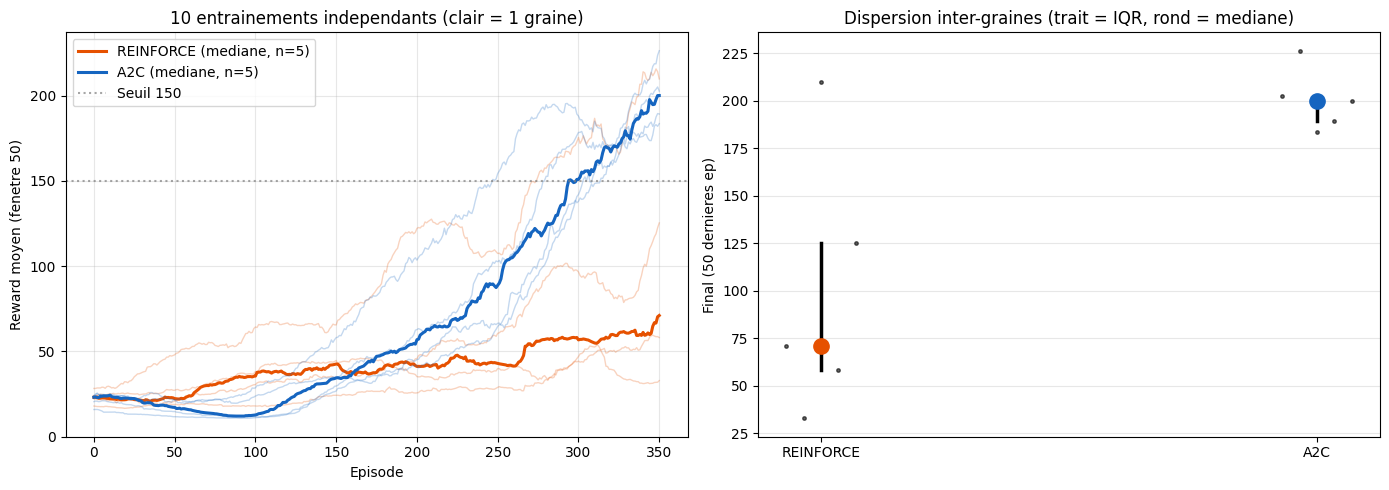

In [9]:
def abl_final(curve, window=50):
    """Performance finale : moyenne des `window` dernieres episodes."""
    return float(np.mean(curve[-window:]))


def abl_episodes_to_reach(curve, threshold, window=50):
    """Premier episode ou la moyenne mobile (window) depasse le seuil.

    Retourne None si le seuil n'est jamais atteint -- un fait a rapporter,
    pas a masquer.
    """
    moving = np.convolve(curve, np.ones(window) / window, mode="valid")
    above = np.nonzero(moving >= threshold)[0]
    return int(above[0] + window) if len(above) else None


abl_stats = {}
for algo in ["REINFORCE", "A2C"]:
    finals = [abl_final(abl_curves[algo][s]) for s in ABL_SEEDS]
    speed = [abl_episodes_to_reach(abl_curves[algo][s], 150.0) for s in ABL_SEEDS]
    reached = [v for v in speed if v is not None]
    abl_stats[algo] = {"finals": finals,
                       "p25": float(np.percentile(finals, 25)),
                       "median": float(np.median(finals)),
                       "p75": float(np.percentile(finals, 75))}
    speed_txt = (f"mediane {int(np.median(reached))} ep "
                 f"(graines atteintes : {len(reached)}/5)")
    if not reached:
        speed_txt = "jamais atteint (0/5 graines)"
    print(f"{algo:10s} | final : mediane {abl_stats[algo]['median']:6.1f} "
          f"[IQR {abl_stats[algo]['p25']:6.1f} - {abl_stats[algo]['p75']:6.1f}] "
          f"| ep. pour atteindre 150 : {speed_txt}")
    print(f"{'':10s} | finales par graine : "
          + ", ".join(f"{v:.0f}" for v in finals))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
abl_colors = {"A2C": "#1565C0", "REINFORCE": "#E65100"}
window = 50
for algo in ["REINFORCE", "A2C"]:
    for s in ABL_SEEDS:
        moving = np.convolve(abl_curves[algo][s], np.ones(window) / window,
                             mode="valid")
        axes[0].plot(moving, color=abl_colors[algo], alpha=0.25, linewidth=1)
    min_len = min(len(abl_curves[algo][s]) for s in ABL_SEEDS)
    stack = np.stack([
        np.convolve(abl_curves[algo][s], np.ones(window) / window, mode="valid")[:min_len]
        for s in ABL_SEEDS
    ])
    axes[0].plot(np.median(stack, axis=0), color=abl_colors[algo],
                 linewidth=2.2, label=f"{algo} (mediane, n=5)")
axes[0].axhline(150, color="gray", linestyle=":", alpha=0.7, label="Seuil 150")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel(f"Reward moyen (fenetre {window})")
axes[0].set_title("10 entrainements independants (clair = 1 graine)")
axes[0].legend()
axes[0].grid(alpha=0.3)

for i, algo in enumerate(["REINFORCE", "A2C"]):
    st = abl_stats[algo]
    axes[1].plot([i, i], [st["p25"], st["p75"]], color="black", linewidth=2.5)
    axes[1].plot(i, st["median"], "o", color=abl_colors[algo], markersize=11,
                 zorder=3)
    for j, v in enumerate(st["finals"]):
        axes[1].plot(i + (j - 2) * 0.035, v, ".", color="black", markersize=5,
                     alpha=0.6)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["REINFORCE", "A2C"])
axes[1].set_ylabel("Final (50 dernieres ep)")
axes[1].set_title("Dispersion inter-graines (trait = IQR, rond = mediane)")
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Interpretation de la mesure

| Algorithme | Final mediane | IQR | Finales par graine | Graines atteignant 150 |
|------------|--------------|-----|--------------------|-----------------------|
| REINFORCE | 71.1 | 58.1 - 125.3 | 71, 33, **210**, 58, 125 | 1/5 (a l'episode 324) |
| A2C | **200.1** | **189.2 - 202.7** | 203, 226, 184, 189, 200 | 5/5 (mediane 344) |

Deux faits lisibles dans le tableau :

1. **La variance inter-graines, pas la moyenne, porte le message.** REINFORCE produit un run a 210 et quatre runs entre 33 et 125 : l'IQR couvre 67 points et une graine isolee (seed 1) fait presque tripler la mediane si on la choisit. A2C tient ses cinq runs dans une bande de 14 points. C'est precisement la reduction de variance annoncee en section 1 -- invisible sur le run unique de la section 7, mesurable ici.
2. **La vitesse ne suit pas.** Sur les graines qui atteignent le seuil, A2C n'y arrive pas plus vite que la graine chanceuse de REINFORCE (344 vs 324 episodes de mediane). Le critic ne rend pas l'apprentissage plus rapide a budget egal sur CartPole : il le rend *reproductible*. Les deux claims sont differents, et seul le second est mesure.

Limite honnete : A2C plafonne a ~200 a 400 episodes dans ce protocole (le run de la section 7 atteignait 390 a 600 episodes). La comparaison est equi-budget mais pas a convergence -- ce qui suffit pour la question de variance posee, pas pour classer les performances finales absolues.

In [10]:
# Exercice 2 : Comparaison A2C vs REINFORCE sur CartPole-v1
#
# Implementez une version simplifiee de REINFORCE (sans baseline) et comparez
# les courbes d'apprentissage avec l'A2C entraine ci-dessus.


def train_reinforce(env_name="CartPole-v1", num_episodes=400, seed=42):
    """
    Entraine un agent REINFORCE (sans baseline) pour comparaison.

    # Indice : Utilisez le meme ActorNetwork mais sans CriticNetwork
    # Indice : La perte REINFORCE est -(log_probs * returns).mean()
    # Etape 1 : Initialisez l'actor et l'optimizer
    # Etape 2 : Pour chaque episode, collectez la trajectoire
    # Etape 3 : Calculez les returns et mettez a jour la politique
    """
    result = None  # TODO etudiant : retourner la liste des episode_rewards
    return result


# TODO etudiant : lancer les deux entrainements et tracer la comparaison
rewards_reinforce = None  # TODO etudiant : train_reinforce()

print("Exercice a completer : implementer REINFORCE et comparer avec A2C")

Exercice a completer : implementer REINFORCE et comparer avec A2C


## 10. Le bonus d'entropie

L'entropie de la politique mesure son **degré d'exploration** :

$$H(\pi) = -\sum_a \pi(a \mid s) \log \pi(a \mid s)$$

- $H$ eleve : la politique est incertaine (exploration)
- $H$ faible : la politique est déterministe (exploitation)

**Pourquoi maximiser l'entropie ?** Sans ce bonus, l'actor peut converger prematurement vers une politique sub-optimale déterministe. Le bonus d'entropie penalise les politiques trop certaines, forcant l'agent a continuer a explorer.

Le coefficient `entropy_coef` (typiquement 0.01) contrôle le compromis exploration/exploitation :
- `entropy_coef = 0` : pas d'encouragement a l'exploration (comme REINFORCE pur)
- `entropy_coef = 0.01` : valeur standard, bon equilibre
- `entropy_coef > 0.1` : forte exploration, peut ralentir la convergence

### Exercice 3 : Ablation du bonus d'entropie

Explorez l'impact du coefficient d'entropie sur l'apprentissage.

**Indices** :
- `# Indice` : entropy_coef = 0 correspond a pas de bonus d'entropie
- `# Indice` : Des valeurs typiques sont 0.0, 0.01, 0.05, 0.1
- `# Indice` : Observez comment l'entropie de la politique evolue pendant l'entrainement

**Étapes** :
- `# Étape 1` : Entrainenez A2C avec plusieurs valeurs de entropy_coef
- `# Étape 2` : Tracez les courbes de reward pour chaque valeur
- `# Étape 3` : Observez la vitesse de convergence et la stabilite finale

In [11]:
# Exercice 3 : Impact du bonus d'entropie sur l'apprentissage
#
# Entrainez A2C avec differentes valeurs de entropy_coef et comparez.

entropy_coefs = [0.0, 0.01, 0.05, 0.1]
results = {}  # TODO etudiant : dict coef -> list of episode_rewards

# TODO etudiant : boucle d'entrainement pour chaque coef
# Indice : reutilisez train_a2c en passant entropy_coef a l'agent
# Etape 1 : Pour chaque coef dans entropy_coefs, entrainez un agent A2C
# Etape 2 : Stockez les rewards dans results[coef]
# Etape 3 : Tracez les courbes comparatives

print("Exercice a completer : ablation du bonus d'entropie")

Exercice a completer : ablation du bonus d'entropie


## 11. Ouverture -- vers PPO et au-dela

A2C est le fondement des algorithmes modernes de RL. Voici les evolutions majeures :

| Algorithme | Innovation par rapport a A2C | Usage |
|------------|------------------------------|-------|
| **A3C** | A2C asynchrone avec plusieurs workers en parallele | Entrainement distribue |
| **PPO** | Objectif clippe pour eviter les trop grosses mises a jour de politique | Standard industrie (SB3, CleanRL) |
| **SAC** | Maximisation de l'entropie comme objectif (pas juste bonus) | Actions continues, sample-efficient |
| **TD3** | Twin critics + delayed policy updates | Actions continues, reduit la surestimation |

**PPO** (Proximal Policy Optimization) est l'algorithme le plus utilise en pratique. Son idee centrale : limiter le changement de politique entre deux mises a jour avec un ratio clippe :

$$\mathcal{L}^{CLIP} = \hat{\mathbb{E}}_t\left[\min\left(r_t(\theta)\hat{A}_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\right)\right]$$

ou $r_t(\theta) = \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{old}}(a_t \mid s_t)}$ est le ratio de probabilites entre la nouvelle et l'ancienne politique.

Les notebooks [RL-1](rl_1_intro_cartpole.ipynb) et [RL-2](rl_2_wrappers_sauvegarde_callbacks.ipynb) de cette serie utilisent PPO via stable-baselines3. Avec les concepts de ce notebook, vous comprenez maintenant ce qui se cache derriere cette boite noire.

## Conclusion

### Recapitulatif des concepts

| Concept | Rôle | Formule |
|---------|------|--------|
| **Actor** | Politique $\pi(a \mid s)$ qui choisit les actions | Sortie : distribution Categorical |
| **Critic** | Valeur $V(s)$ qui estime la qualite des etats | Sortie : scalaire |
| **Avantage** | Signal d'apprentissage a variance reduite | $A_t = G_t - V(s_t)$ |
| **Entropy bonus** | Encourage l'exploration | $H(\pi) = -\sum_a \pi(a \mid s) \log \pi(a \mid s)$ |
| **Gradient clipping** | Stabilise les mises a jour | `clip_grad_norm_(max_norm=1.0)` |

### Comparaison des approches

| Aspect | DQN | REINFORCE | A2C |
|--------|-----|-----------|-----|
| Apprend | $Q(s,a)$ | $\pi(a \mid s)$ | $\pi(a \mid s)$ + $V(s)$ |
| Variance | Faible | Haute | Moyenne |
| Efficacite données | Elevee (off-policy) | Faible (on-policy) | Moyenne |
| Actions continues | Non | Oui | Oui |
| Stabilite | Bonne (target net) | Variable | Bonne (gradient clipping) |

**Prochaine étape** : Le notebook [RL-7 Multi-Agent](rl_7_multi_agent_rl.ipynb) aborder l'apprentissage multi-agent ou plusieurs agents interagissent simultanement dans un environnement partage.

**References** :
- Sutton & Barto, *Reinforcement Learning: An Introduction*, Chapters 13 (Policy Gradient) et 15 (Neural RL)
- Mnih et al. (2016) - *Asynchronous Methods for Deep RL* (A3C)
- Schulman et al. (2017) - *Proximal Policy Optimization Algorithms* (PPO)


### References academiques

- Williams, R.J. (1992). Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning. Neural Computation 4(3):405-414.
- Konda, V.R. & Tsitsiklis, J.N. (2003). On Actor-Critic Algorithms. SIAM Journal on Control and Optimization 42(4):1143-1166.
- Mnih, V., Badia, A.P., Mirza, M., Graves, A., Lillicrap, T., Harley, T., Silver, D. & Kavukcuoglu, K. (2016). Asynchronous Methods for Deep Reinforcement Learning. ICML 2016. arXiv:1602.01783.
- Sutton, R.S., McAllester, D.A., Singh, S.P. & Mansour, Y. (2000). Policy Gradient Methods for Reinforcement Learning with Function Approximation. NeurIPS 2000.
- Sutton, R.S. & Barto, A.G. (2018). Reinforcement Learning: An Introduction (2nd ed.). MIT Press.

